# Ejemplo 2. Trayectoria de Regularización de la Regresión Logística con L1


### Cargar datos

In [13]:
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

In [14]:
X = X[y != 2]
y = y[y != 2]

### Compute regularization path

In [15]:
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import l1_min_c

cs = l1_min_c(X, y, loss="log") * np.logspace(0, 1, 16)

In [16]:
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty='l1',
        solver="liblinear",
        tol=1e-6,
        max_iter=int(1e6),
        warm_start=True,
        fit_intercept=False,
    ),
)
coefs_ = []
for c in cs:
    clf.set_params(logisticregression__C=c)
    clf.fit(X, y)
    coefs_.append(clf["logisticregression"].coef_.ravel().copy())

coefs_ = np.array(coefs_)

### Plot regularization path

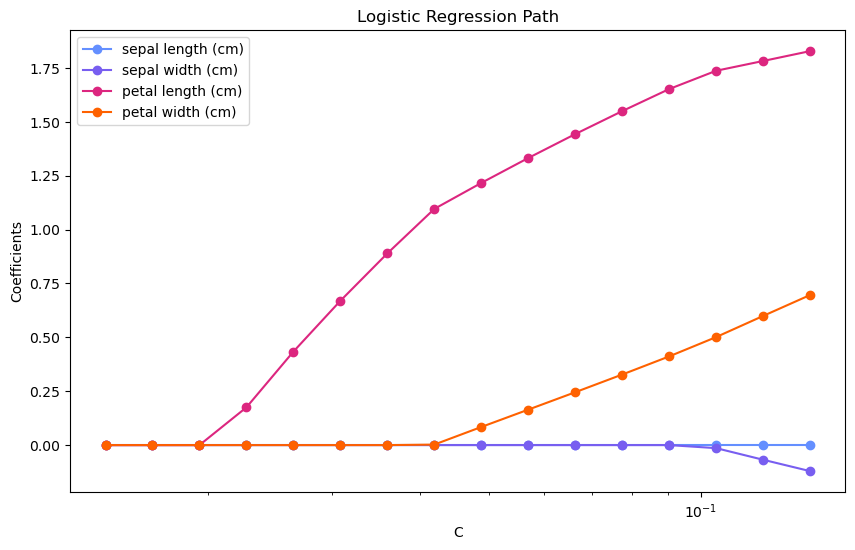

In [17]:
import matplotlib.pyplot as plt

# Colorblind-friendly palette (IBM Color Blind Safe palette)
colors = ["#648FFF", "#785EF0", "#DC267F", "#FE6100"]

plt.figure(figsize=(10, 6))
for i in range(coefs_.shape[1]):
    plt.semilogx(cs, coefs_[:, i], marker="o", color=colors[i], label=feature_names[i])

ymin, ymax = plt.ylim()
plt.xlabel("C")
plt.ylabel("Coefficients")
plt.title("Logistic Regression Path")
plt.legend()
plt.axis("tight")
plt.show()

### Preguntas

##### ¿Qué observas en la trayectoria de regularización cuando aumentas la fuerza de regularización?

Se puede observar que a mideda que disminuye C los valores de los coeficientes se hacen más pequeños, van hacia cero. En la gráfica se puede observar como algunos coeficientes llegan a cero.

##### ¿Cómo afectan los diferentes niveles de regularización a los coeficientes del modelo?

Los niveles de regularización de forma que con una fuerte los coeficientes se reducen y anulan, con una regularización débil los coeficientes aumentan su magnitud y más variables influyen en el modelo.

##### ¿Qué patrones de cambio en los coeficientes puedes identificar?

Se observa que los coeficientes se activan de forma gradual conforme la regularización, algunos se empiezan a mover antes y otros como sepal width se mueven casi al final.

##### ¿Cómo podrías utilizar la trayectoria de regularización para seleccionar la fuerza de regularización óptima?

Se observa la trayectoria y eliges un valor de C donde los coeficientes relevantes ya son distintos de cero y se mantienen estables.

##### ¿Qué impacto tiene la regularización en la capacidad del modelo para generalizar?

Tiene impacto en que controla la complejidad del modelo. Una regularización adecuada evita el sobreajuste, mientras que una regularización excesiva produce subajuste y una regularización insuficiente reduce la capacidad de generalizar.